# Fine-Tuning Your Model

<a href="https://colab.research.google.com/github/marcinsawinski/UEP_KIE_ML_CLASS/blob/main/dc_supervised_student/03_Fine-tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Having trained models, now you will learn how to evaluate them. In this chapter, you will be introduced to several metrics along with a visualization technique for analyzing classification model performance using scikit-learn. You will also learn how to optimize classification and regression models through the use of hyperparameter tuning.

## Assessing a diabetes prediction classifier
In this chapter you'll work with the diabetes_df dataset introduced previously.

The goal is to predict whether or not each individual is likely to have diabetes based on the features body mass index (BMI) and age (in years). Therefore, it is a binary classification problem. A target value of 0 indicates that the individual does not have diabetes, while a value of 1 indicates that the individual does have diabetes.

diabetes_df has been preloaded for you as a pandas DataFrame and split into X_train, X_test, y_train, and y_test. In addition, a KNeighborsClassifier() has been instantiated and assigned to knn.

You will fit the model, make predictions on the test set, then produce a confusion matrix and classification report.

### Instructions

 - Import confusion_matrix and classification_report.
 - Fit the model to the training data.
 - Predict the labels of the test set, storing the results as y_pred.
 - Assessing a diabetes prediction classifier
 - Compute and print the confusion matrix and classification report for the test labels versus the predicted labels.

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
diabetes_df = pd.read_csv("../datasets/dc_datasets/diabetes_clean.csv")
diabetes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   pregnancies  768 non-null    int64  
 1   glucose      768 non-null    int64  
 2   diastolic    768 non-null    int64  
 3   triceps      768 non-null    int64  
 4   insulin      768 non-null    int64  
 5   bmi          768 non-null    float64
 6   dpf          768 non-null    float64
 7   age          768 non-null    int64  
 8   diabetes     768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
X = diabetes_df[["bmi", "age"]].values
y = diabetes_df["diabetes"].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [5]:
# Import confusion matrix
from sklearn.metrics import confusion_matrix, classification_report

knn = KNeighborsClassifier(n_neighbors=6)

# Fit the model to the training data
knn.fit(X_train, y_train)

# Predict the labels of the test data: y_pred
y_pred = knn.predict(X_test)

# Generate the confusion matrix and classification report
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[134  16]
 [ 62  19]]
              precision    recall  f1-score   support

           0       0.68      0.89      0.77       150
           1       0.54      0.23      0.33        81

    accuracy                           0.66       231
   macro avg       0.61      0.56      0.55       231
weighted avg       0.63      0.66      0.62       231



## Building a logistic regression model
In this exercise, you will build a logistic regression model using all features in the diabetes_df dataset. The model will be used to predict the probability of individuals in the test set having a diabetes diagnosis.

The diabetes_df dataset has been split into X_train, X_test, y_train, and y_test, and preloaded for you.

### Instructions

 - Import LogisticRegression.
 - Instantiate a logistic regression model, logreg.
 - Fit the model to the training data.
 - Predict the probabilities of each individual in the test set having a diabetes diagnosis, storing the array of positive probabilities as y_pred_probs.

In [11]:
X = diabetes_df.drop(columns="diabetes").values
y = diabetes_df["diabetes"].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [7]:
# Import LogisticRegression
from sklearn.linear_model import LogisticRegression

# Instantiate the model
logreg = LogisticRegression()

# Fit the model
logreg.fit(X_train, y_train)

# Predict probabilities
y_pred_probs = logreg.predict_proba(X_test)[:,1]

print(y_pred_probs[:10])

[0.25205435 0.30805034 0.61058576 0.50718353 0.69934247 0.1169024
 0.42813302 0.13818001 0.15706071 0.5323531 ]


## The ROC curve
Now you have built a logistic regression model for predicting diabetes status, you can plot the ROC curve to visualize how the true positive rate and false positive rate vary as the decision threshold changes.

The test labels, y_test, and the predicted probabilities of the test features belonging to the positive class, y_pred_probs, have been preloaded for you, along with matplotlib.pyplot as plt.

You will create a ROC curve and then interpret the results.

### Instructions
 - Import roc_curve.
 - Calculate the ROC curve values, using y_test and y_pred_probs, and unpacking the results into fpr, tpr, and thresholds.
 - Plot true positive rate against false positive rate.

In [9]:
import matplotlib.pyplot as plt

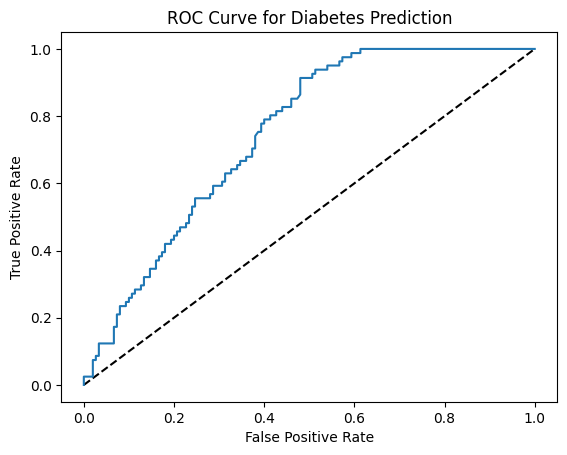

In [10]:
# Import roc_curve
from sklearn.metrics import roc_curve

# Generate ROC curve values: fpr, tpr, thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)

plt.plot([0, 1], [0, 1], 'k--')

# Plot tpr against fpr
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Diabetes Prediction')
plt.show()

## ROC AUC
The ROC curve you plotted in the last exercise looked promising.

Now you will compute the area under the ROC curve, along with the other classification metrics you have used previously.

The confusion_matrix and classification_report functions have been preloaded for you, along with the logreg model you previously built, plus X_train, X_test, y_train, y_test. Also, the model's predicted test set labels are stored as y_pred, and probabilities of test set observations belonging to the positive class stored as y_pred_probs.

A knn model has also been created and the performance metrics printed in the console, so you can compare the roc_auc_score, confusion_matrix, and classification_report between the two models.

### Instructions

 - Import roc_auc_score.
 - Calculate and print the ROC AUC score, passing the test labels and the predicted positive class probabilities.
 - Calculate and print the confusion matrix.
 - Call classification_report().

In [11]:
# Import roc_auc_score
from sklearn.metrics import roc_auc_score

# Calculate roc_auc_score
print(roc_auc_score(y_test, y_pred_probs))

# Calculate the confusion matrix
print(confusion_matrix(y_test, y_pred))

# Calculate the classification report
print(classification_report(y_test, y_pred))

0.7460082304526748
[[134  16]
 [ 62  19]]
              precision    recall  f1-score   support

           0       0.68      0.89      0.77       150
           1       0.54      0.23      0.33        81

    accuracy                           0.66       231
   macro avg       0.61      0.56      0.55       231
weighted avg       0.63      0.66      0.62       231



## Hyperparameter tuning with GridSearchCV
Now you have seen how to perform grid search hyperparameter tuning, you are going to build a lasso regression model with optimal hyperparameters to predict blood glucose levels using the features in the diabetes_df dataset.

X_train, X_test, y_train, and y_test have been preloaded for you. A KFold() object has been created and stored for you as kf, along with a lasso regression model as lasso.

### Instructions
 - Import GridSearchCV.
 - Set up a parameter grid for "alpha", using np.linspace() to create 20 evenly spaced values ranging from 0.00001 to 1.
 - Call GridSearchCV(), passing lasso, the parameter grid, and setting cv equal to kf.
 - Fit the grid search object to the training data to perform a cross-validated grid search.

In [22]:
import numpy as np
from sklearn.linear_model import Lasso
from sklearn.model_selection import KFold

lasso = Lasso()
kf = KFold(n_splits=5, random_state=42, shuffle=True)

In [ ]:
# Import GridSearchCV
____

# Set up the parameter grid
param_grid = {"____": np.linspace(____, ____, ____)}

# Instantiate lasso_cv
lasso_cv = ____(____, ____, cv=____)

# Fit to the training data
____
print("Tuned lasso paramaters: {}".format(lasso_cv.best_params_))
print("Tuned lasso score: {}".format(lasso_cv.best_score_))

## Hyperparameter tuning with RandomizedSearchCV
As you saw, GridSearchCV can be computationally expensive, especially if you are searching over a large hyperparameter space. In this case, you can use RandomizedSearchCV, which tests a fixed number of hyperparameter settings from specified probability distributions.

Training and test sets from diabetes_df have been pre-loaded for you as X_train. X_test, y_train, and y_test, where the target is "diabetes". A logistic regression model has been created and stored as logreg, as well as a KFold variable stored as kf.

You will define a range of hyperparameters and use RandomizedSearchCV, which has been imported from sklearn.model_selection, to look for optimal hyperparameters from these options.

### Instructions

 - Create params, adding "l1" and "l2" as penalty values, setting C to a range of 50 float values between 0.1 and 1.0, and class_weight to either "balanced" or a dictionary containing 0:0.8, 1:0.2.
 - Create the Randomized Search CV object, passing the model and the parameters, and setting cv equal to kf.
 - Fit logreg_cv to the training data.
 - Print the model's best parameters and accuracy score.

In [24]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
# Create the parameter space
params = {"penalty": ["____", "____"],
         "tol": np.linspace(0.0001, 1.0, 50),
         "C": np.linspace(____, ____, ____),
         "class_weight": ["____", {0:____, 1:____}]}

# Instantiate the RandomizedSearchCV object
logreg_cv = ____(____, ____, cv=____)

# Fit the data to the model
logreg_cv.____(____, ____)

# Print the tuned parameters and score
print("Tuned Logistic Regression Parameters: {}".format(____.____))
print("Tuned Logistic Regression Best Accuracy Score: {}".format(____.____))